In [42]:
import jax
import jax.numpy as jnp
import immrax as irx
print(jax.devices())

[CudaDevice(id=0)]


In [43]:

from immutabledict import immutabledict
from faulty_nonholonomic_car import FaultyNonHolonomicCar
# Define initial state bounds (intervals) using icentpert
from typing import Union


#

car_system = FaultyNonHolonomicCar()

faulty_car_embedding_system = irx.natemb(car_system)
print(faulty_car_embedding_system)
# Define the initial interval of states
x0 = jnp.zeros(4)
x0_perturbation = jnp.array([.02, .02, .02, .02])
x0_interval = irx.icentpert(x0, x0_perturbation)

# Define the fixed control input and disturbance
u_fixed = jnp.array([1, 1])  # Fixed control input
u_interval = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
w_fixed = jnp.array([jnp.pi/4])  # Fixed disturbance. Assume steering angle is fixed at 45 deg.
w_interval = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
p_interval_no_fault = irx.icentpert(jnp.array([1.]), jnp.zeros(1))
p_interval = irx.icentpert(jnp.array([0]), jnp.array([.0]))
# Propagate the interval for 1 second
t_end = 1.0  # 1 second
def u_map_in_func(t, x):
    return u_fixed
def w_map_in_func(t, x):
    return w_fixed
def p_map_in_func(t, x):
    return p_interval
# faulty_car_embedding_system.f(0, x0_interval, u_fixed, w_fixed, p_interval)
x_trajectory_actuator_fault = faulty_car_embedding_system.compute_trajectory(0., t_end, irx.i2ut(x0_interval), (u_map_in_func, w_map_in_func, p_map_in_func))
 

# Print the resulting interval of states
print("Initial interval of states:", x0_interval)
print("Final interval of states after 1 second:", x_trajectory_actuator_fault)

Initial interval of states: [[(-0.02, 0.02)]
 [(-0.02, 0.02)]
 [(-0.02, 0.02)]
 [(-0.02, 0.02)]]
Final interval of states after 1 second: <immrax.system.Trajectory object at 0x736cb6219590>


In [44]:
print(jax.devices('gpu'))

[CudaDevice(id=0)]


In [45]:
def propagate_interval(
        embedding_system: irx.System, 
        x0_interval: irx.Interval, 
        u_interval: Union[jnp.ndarray, irx.Interval], 
        w_interval: Union[jnp.ndarray, irx.Interval], 
        p_interval: Union[jnp.ndarray, irx.Interval], 
        t_end: float
    ) -> irx.Interval:
    def u_map_in_func(t, x):
        return u_interval
    def w_map_in_func(t, x):
        return w_interval
    def p_map_in_func(t, x):
        return p_interval
    x_traj = embedding_system.compute_trajectory(0.0, t_end, irx.i2ut(x0_interval), (u_map_in_func, w_map_in_func, p_map_in_func))
    x_emb = x_traj.ys[-1]
    x_ivl = irx.Interval(lower=x_emb[:4], upper=x_emb[4:])
    return x_ivl

In [46]:
def propagate_interval_euler(
        embedding_system: irx.System, 
        x0_interval: irx.Interval, 
        u_interval: Union[jnp.ndarray, irx.Interval], 
        w_interval: Union[jnp.ndarray, irx.Interval], 
        p_interval: Union[jnp.ndarray, irx.Interval], 
        t_end: float
    ) -> irx.Interval:
    xt_ut =  embedding_system.f(0., irx.i2ut(x0_interval), u_interval, w_interval, p_interval) * t_end + irx.i2ut(x0_interval)
    return irx.ut2i(xt_ut)

In [47]:
x_emb_actuator_fault = x_trajectory_actuator_fault.ys[-1]
x_interval_actuator_fault = irx.Interval(lower=x_emb_actuator_fault[:4], upper=x_emb_actuator_fault[4:])

Generate Interval WITHOUT Actuator Fault

In [48]:
normal_car_system = FaultyNonHolonomicCar()
normal_car_embedding_system = irx.natemb(normal_car_system)
# Define the initial interval of states
x0 = jnp.zeros(4)
x0_perturbation = jnp.array([.02, .02, .02, .02])
x0_interval = irx.icentpert(x0, x0_perturbation)

# Define the fixed control input and disturbance
u_fixed = jnp.array([0.2, 0.2])  # Fixed control input
w_fixed = jnp.array([jnp.pi/4.0])  # Fixed disturbance. Assume steering angle is fixed at 45 deg.

# Propagate the interval for 1 second
t_end = 1.0  # 1 second
p_no_disturbance = irx.icentpert(jnp.array([.25]), jnp.array([.25]))

x_trajectory_no_fault = normal_car_embedding_system.compute_trajectory(0, t_end, irx.i2ut(x0_interval), (u_map_in_func, w_map_in_func, p_map_in_func))

# Print the resulting interval of states
print("Initial interval of states:", x0_interval)
print("Final interval of states after 1 second:", x_trajectory_no_fault)

Initial interval of states: [[(-0.02, 0.02)]
 [(-0.02, 0.02)]
 [(-0.02, 0.02)]
 [(-0.02, 0.02)]]
Final interval of states after 1 second: <immrax.system.Trajectory object at 0x736cb5a51c10>


In [49]:
x_emb_no_fault = x_trajectory_no_fault.ys[-1]
x_interval_no_fault = irx.Interval(lower=x_emb_no_fault[:4], upper=x_emb_no_fault[4:])

Add an observation fault

In [50]:
offset = jnp.array([0.2, 0.2, 0., 0.2])
x_interval_observation_fault = x_interval_no_fault + offset

Plot observation of system

In [51]:
import matplotlib.pyplot as plt
def plot_observation_boxes(x_interval_actuator_fault, x_interval_no_fault, x_interval_observation_fault, starting_observation=x0_interval, new_observation_interval=None, new_observation=None):
    # Extract the x and y positions from the final interval
    x_pos_interval_actuator_fault = x_interval_actuator_fault[0]  # x position interval
    y_pos_interval_actuator_fault = x_interval_actuator_fault[1]  # y position interval
    x_pos_interval_no_fault = x_interval_no_fault[0]
    y_pos_interval_no_fault = x_interval_no_fault[1]
    x_pos_interval_observation_fault = x_interval_observation_fault[0]
    y_pos_interval_observation_fault = x_interval_observation_fault[1]

    # Plot the interval of x and y positions
    plt.figure(figsize=(8, 6))
    plt.fill_between(
        [x_pos_interval_actuator_fault.lower, x_pos_interval_actuator_fault.upper],
        [y_pos_interval_actuator_fault.lower, y_pos_interval_actuator_fault.lower],
        [y_pos_interval_actuator_fault.upper, y_pos_interval_actuator_fault.upper],
        alpha=0.5,
        color="blue",
        label="Observation Set (x, y) - Actuator Fault"
    )
    plt.fill_between(
        [x_pos_interval_no_fault.lower, x_pos_interval_no_fault.upper],
        [y_pos_interval_no_fault.lower, y_pos_interval_no_fault.lower],
        [y_pos_interval_no_fault.upper, y_pos_interval_no_fault.upper],
        alpha=0.5,
        color="green",
        label="Observation Set (x, y) - No Fault"
    )
    plt.fill_between(
        [x_pos_interval_observation_fault.lower, x_pos_interval_observation_fault.upper],
        [y_pos_interval_observation_fault.lower, y_pos_interval_observation_fault.lower],
        [y_pos_interval_observation_fault.upper, y_pos_interval_observation_fault.upper],
        alpha=0.5,
        color="yellow",
        label="Observation Set (x, y) - Observer Fault"
    )
    plt.fill_between(
        [starting_observation.lower[0], starting_observation.upper[0]],
        [starting_observation.lower[1], starting_observation.lower[1]],
        [starting_observation.upper[1], starting_observation.upper[1]],
        color="red",
        label="Starting Observation"
    )
    if new_observation_interval:
        plt.fill_between(
            [new_observation_interval.lower[0], new_observation_interval.upper[0]],
            [new_observation_interval.lower[1], new_observation_interval.lower[1]],
            [new_observation_interval.upper[1], new_observation_interval.upper[1]],
            color="cyan",
            label="Interval Containing New Observation"
        )    
    try:
        plt.plot(new_observation[0], new_observation[1], "mo", label="Actual New Observation")
    except:
        pass
    plt.xlabel("x position")
    plt.ylabel("y position")
    plt.title("Observation of x and y Positions after 1 Second")
    plt.legend()
    plt.grid()
    plt.show()

In [52]:
faulty_car_embedding_system.f(0, irx.i2ut(x0_interval), u_interval, w_interval, p_interval) 

Array([-2.0000000e-02, -3.9997330e-04,  7.8539819e-01,  1.7853982e+00,
        2.0000000e-02,  3.9997330e-04,  7.8539819e-01,  1.7853982e+00],      dtype=float32)

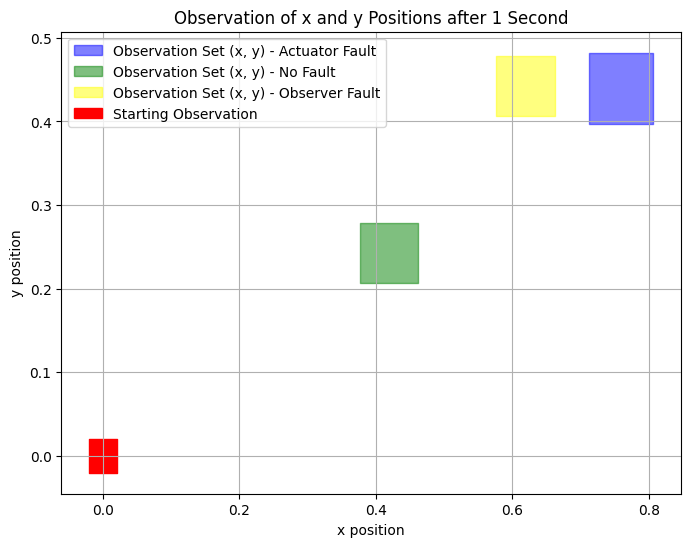

In [53]:
import matplotlib.pyplot as plt
# Extract the x and y positions from the final interval
x_pos_interval_actuator_fault = x_interval_actuator_fault[0]  # x position interval
y_pos_interval_actuator_fault = x_interval_actuator_fault[1]  # y position interval
x_pos_interval_no_fault = x_interval_no_fault[0]
y_pos_interval_no_fault = x_interval_no_fault[1]
x_pos_interval_observation_fault = x_interval_observation_fault[0]
y_pos_interval_observation_fault = x_interval_observation_fault[1]

# Plot the interval of x and y positions
plt.figure(figsize=(8, 6))
plt.fill_between(
    [x_pos_interval_actuator_fault.lower, x_pos_interval_actuator_fault.upper],
    [y_pos_interval_actuator_fault.lower, y_pos_interval_actuator_fault.lower],
    [y_pos_interval_actuator_fault.upper, y_pos_interval_actuator_fault.upper],
    alpha=0.5,
    color="blue",
    label="Observation Set (x, y) - Actuator Fault"
)
plt.fill_between(
    [x_pos_interval_no_fault.lower, x_pos_interval_no_fault.upper],
    [y_pos_interval_no_fault.lower, y_pos_interval_no_fault.lower],
    [y_pos_interval_no_fault.upper, y_pos_interval_no_fault.upper],
    alpha=0.5,
    color="green",
    label="Observation Set (x, y) - No Fault"
)
plt.fill_between(
    [x_pos_interval_observation_fault.lower, x_pos_interval_observation_fault.upper],
    [y_pos_interval_observation_fault.lower, y_pos_interval_observation_fault.lower],
    [y_pos_interval_observation_fault.upper, y_pos_interval_observation_fault.upper],
    alpha=0.5,
    color="yellow",
    label="Observation Set (x, y) - Observer Fault"
)
plt.fill_between(
    [x0_interval.lower[0], x0_interval.upper[0]],
    [x0_interval.lower[1], x0_interval.lower[1]],
    [x0_interval.upper[1], x0_interval.upper[1]],
    color="red",
    label="Starting Observation"
)
plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Observation of x and y Positions after 1 Second")
plt.legend()
plt.grid()
plt.show()

In [54]:
def overlap_size(interval1, interval2):
    # Compute the intersection lower and upper bounds
    intersection_lower = jnp.maximum(interval1.lower, interval2.lower)
    intersection_upper = jnp.minimum(interval1.upper, interval2.upper)
    print(intersection_lower)
    print(intersection_upper)
    # Calculate the size of the intersection
    if jnp.any(intersection_upper < intersection_lower):
        return jnp.array(0.0)  # No overlap
    else:
        intersection_size = jnp.prod(intersection_upper - intersection_lower)
        return intersection_size

In [55]:
interval1 = irx.interval(jnp.array([2, 5]), jnp.array([3, 6]))
interval2 = irx.interval(jnp.array([2, 5]), jnp.array([3, 6]))
overlap_size(interval1, interval2)
# jnp.zeros(1)


[2 5]
[3 6]


Array(1, dtype=int32)

In [56]:
def actuator_observer_intervals_given_u(x0_interval, u_fixed):
    u_interval_if = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
    w_interval_if = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
    x_interval_no_fault = propagate_interval_euler(irx.natemb(normal_car_system), x0_interval, u_interval_if, w_interval_no_fault, p_no_disturbance, t_end)
    x_interval_actuator_fault = propagate_interval_euler(irx.natemb(car_system), x0_interval=x0_interval, u_interval=u_interval_if, w_interval=w_interval_if, p_interval=p_interval, t_end=t_end)
    x_interval_observation_fault = x_interval_no_fault + offset
    return x_interval_actuator_fault, x_interval_observation_fault

In [57]:
def actuator_observer_fault_overlap(x0_interval, u_fixed):
    u_interval_if = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
    w_interval_if = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
    x_interval_no_fault = propagate_interval_euler(irx.natemb(normal_car_system), x0_interval, u_interval_if, w_interval_no_fault, p_no_disturbance, t_end)
    x_interval_actuator_fault = propagate_interval_euler(irx.natemb(car_system), x0_interval=x0_interval, u_interval=u_interval_if, w_interval=w_interval_if, p_interval=p_interval, t_end=t_end)
    x_interval_observation_fault = x_interval_no_fault + offset
    return overlap_size(x_interval_actuator_fault, x_interval_observation_fault)

In [58]:
def actuator_nominal_overlap(x0_interval, u_fixed):
    u_interval_if = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
    w_interval_if = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
    x_interval_no_fault = propagate_interval_euler(irx.natemb(normal_car_system), x0_interval, u_interval_if, w_interval_no_fault, p_no_disturbance, t_end)
    x_interval_actuator_fault = propagate_interval_euler(irx.natemb(car_system), x0_interval=x0_interval, u_interval=u_interval_if, w_interval=w_interval_if, p_interval=p_interval, t_end=t_end)
    return overlap_size(x_interval_actuator_fault, x_interval_no_fault)

In [59]:
from jax.scipy.optimize import minimize
def minimize_control_input_no_fault(x_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, dt):
    # Define the objective function
    def objective(u):
        return actuator_nominal_overlap(x_interval, u)

    # Initial guess for control input
    u_init = jnp.zeros(2)  # Example: 2D control input

    # Minimize the objective function
    result = minimize(objective, u_init, method="BFGS")
    print("Optimization result: ")
    print(result.success)
    return result.x

In [60]:
import jax
from jax import value_and_grad
from jax.scipy.optimize import minimize
def minimize_control_input(x_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, dt):
    # Define the objective function
    def objective(u):
        return actuator_observer_fault_overlap(x_interval, u)

    # Initial guess for control input
    u_init = jnp.zeros(2)  # Example: 2D control input

    # Minimize the objective function
    result = minimize(objective, u_init, method="BFGS")
    return result.x

def is_outside(interval1, interval2):
    # Check if interval1 is fully outside interval2
    return jnp.all(interval1.upper < interval2.lower) or jnp.all(interval1.lower > interval2.upper)

from jax import random

def get_noisy_measurement(x, delta, key):
    """
    Returns a random interval that is δ-wide and contains the true output.

    Args:
        x_interval (array): The true output interval (lower and upper bounds).
        delta (float): The noise level (width of the interval).
        key (jax.random.PRNGKey): Random key for JAX's random number generator.

    Returns:
        Interval: A noisy interval containing the true output.
    """


    # Generate random noise for lower and upper bounds
    key, subkey = random.split(key)
    noise_lower = random.uniform(subkey, shape=x.shape, minval=-delta, maxval=0)  # Noise for lower bound
    key, subkey = random.split(key)
    noise_upper = random.uniform(subkey, shape=x.shape, minval=0, maxval=delta)  # Noise for upper bound

    # Compute noisy bounds
    noisy_lower = x + noise_lower
    noisy_upper = x + noise_upper


    # Return the noisy interval
    return irx.Interval(lower=noisy_lower, upper=noisy_upper)


In [61]:
import jax
def armijo_step_size(u, x0_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, grad_u, alpha_init=1.0, c=0.5, tau=0.5, max_iter=100):
    """
    Perform backtracking line search to find a step size that satisfies the Armijo condition.

    Args:
        u: Current control input.
        grad_u: Gradient of the objective function at u.
        alpha_init: Initial step size.
        c: Constant for the Armijo condition (typically 0.5).
        tau: Reduction factor for the step size (typically 0.5).
        max_iter: Maximum number of iterations for the line search.

    Returns:
        alpha: Step size that satisfies the Armijo condition.
    """
    alpha = alpha_init
    f_u = actuator_observer_fault_overlap(x0_interval,u, )
    grad_norm_sq = jnp.sum(grad_u**2)  # Squared norm of the gradient

    for _ in range(max_iter):
        # Compute the candidate update
        u_new = u - alpha * grad_u
        f_u_new = actuator_observer_fault_overlap(x0_interval, u_new)

        # Check the Armijo condition
        if f_u_new <= f_u - c * alpha * grad_norm_sq:
            return alpha  # Step size satisfies the condition

        # Reduce the step size
        alpha = tau * alpha

    return alpha  
# Gradient descent with Armijo rule
def gradient_descent_armijo(u_init, x0_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, alpha_init=10, c=0.5, tau=0.5, max_iter=5, tol=1e-3):
    """
    Perform gradient descent with Armijo rule to minimize the objective function.

    Args:
        u_init: Initial guess for the control input.
        alpha_init: Initial step size for the Armijo rule.
        c: Constant for the Armijo condition.
        tau: Reduction factor for the step size.
        max_iter: Maximum number of iterations.
        tol: Tolerance for convergence.

    Returns:
        u_opt: Optimal control input.
    """
    def actuator_observer_intervals_given_x(u_fixed):
        u_interval_if = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
        w_interval_if = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
        x_interval_no_fault = propagate_interval_euler(irx.natemb(normal_car_system), x0_interval, u_interval_if, w_interval_no_fault, p_no_disturbance, t_end)
        x_interval_actuator_fault = propagate_interval_euler(irx.natemb(car_system), x0_interval=x0_interval, u_interval=u_interval_if, w_interval=w_interval_if, p_interval=p_interval, t_end=t_end)
        x_interval_observation_fault = x_interval_no_fault# + offset
        # print(f"Intervals: actuator fault: {x_interval_actuator_fault}, observer fault: {x_interval_observation_fault}")
        return x_interval_actuator_fault, x_interval_observation_fault

    def actuator_observer_fault_overlap_given_x(u_fixed):
        x_interval_actuator_fault, x_interval_observation_fault = actuator_observer_intervals_given_x(u_fixed)
        return overlap_size(x_interval_actuator_fault, x_interval_observation_fault)
    u = u_init
    
    aofo_grad = jax.jacrev(actuator_observer_fault_overlap_given_x)
    for i in range(max_iter):
        # Compute the gradient
        grad_u = aofo_grad(u)
        # print(grad_u)
        # print(jnp.linalg.norm(grad_u))
        # Check for convergence
        print(f"At iteration {i}, Gradient is {grad_u} and overlap area is {actuator_observer_fault_overlap_given_x(u)}")
        if jnp.linalg.norm(grad_u) < tol or actuator_observer_fault_overlap_given_x(u) < tol:
            print(f"Converged after {i} iterations.")
            break

        # Compute step size using Armijo rule
        alpha = armijo_step_size(u, x0_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, grad_u, alpha_init, c, tau)

        # Update the control input
        u = u - alpha * grad_u
    else:
        print(f"Reached maximum iterations ({max_iter}).")

    return u

In [62]:
from jax import random
rng_key = random.PRNGKey(42)
real_car_system = FaultyNonHolonomicCar()
def fault_detection(x0_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, dt, max_iter=100):
    fault_cases = ["actuator", "observer"]  # Initial fault cases
    x_interval = x0_interval
    x_actual = jnp.zeros(4)
    t = 0
    for i in range(max_iter):
        # Compute optimal control input
        u_opt = gradient_descent_armijo(jnp.zeros(2),x_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, dt)
        # u_opt = minimize_control_input_no_fault(
        #     x_interval=x_interval, 
        #     w_interval=w_interval, 
        #     p_no_disturbance=p_no_disturbance, 
        #     p_actuator_fault=p_actuator_fault, 
        #     observer_offset=observer_offset, dt=dt
        #     )
        print(f"u_opt is {u_opt}")
        previous_observation_interval = x_interval
        previous_state = x_actual
        # Propagate system with optimal control input
        x_interval_no_fault = propagate_interval(normal_car_embedding_system, x_interval, u_opt, w_interval_no_fault, p_no_disturbance, dt)
        x_interval_actuator_fault = propagate_interval(faulty_car_embedding_system, x_interval, u_opt, w_interval, p_actuator_fault, dt)
        x_interval_observer_fault = x_interval_no_fault #+ observer_offset
        def u_map_in_func(t, x):
            return u_opt
        def w_map_in_func(t, x):
            return jnp.array([0, 0])
        def p_map_in_func(t, x):
            return jnp.array([0])
        real_traj = real_car_system.compute_trajectory(0.0, t + dt, previous_state, (u_map_in_func, w_map_in_func, p_map_in_func))
        x_actual = real_traj.ys[-1]
        print(f"x_interval_actuator_fault: {x_interval_actuator_fault[0:2]}")
        print(f"x_interval_observer_fault: {x_interval_observer_fault[0:2]}")
        overlap_size_this_i = overlap_size(x_interval_actuator_fault[0:2], x_interval_observer_fault[0:2])
        # Obtain noisy measurement (δ-wide interval)
        print(f"At time step {i}, overlap size is {overlap_size_this_i}")
        measurement_interval = get_noisy_measurement(x_actual, delta=0.02, key=rng_key)

        # Check if measurement is outside fault case intervals
        if is_outside(measurement_interval[0:2], x_interval_actuator_fault[0:2]) and "actuator" in fault_cases:
            fault_cases.remove("actuator")
        if is_outside(measurement_interval[0:2], x_interval_observer_fault[0:2]) and "observer" in fault_cases:
            fault_cases.remove("observer")

        t += dt

        print(f"Time: {t}s")
        print(f"Applied control effort: {u_opt}")
        plot_observation_boxes(
            x_interval_no_fault=x_interval_no_fault, 
            x_interval_actuator_fault=x_interval_actuator_fault, 
            x_interval_observation_fault=x_interval_observer_fault,
            starting_observation=previous_observation_interval,
            new_observation_interval=measurement_interval,
            new_observation=x_actual[0:2]
        )

        # Update state interval
        x_interval = measurement_interval

        # If only one fault case remains, return it
        if len(fault_cases) == 1:
            return fault_cases[0]
        
        if len(fault_cases) == 0:
            return "None"

    return "unknown"  # If max_iter is reached without conclusion

In [63]:
import jax.lax as lax

# Your new, JAX-compatible function
def overlap_size_lax(interval1, interval2):
    # Calculate intersection bounds (this part is fine)
    intersection_lower = jnp.maximum(interval1.lower, interval2.lower)
    intersection_upper = jnp.minimum(interval1.upper, interval2.upper)

    # Define the two functions for the conditional branches.
    # They must take the same arguments (the 'operands').
    def has_overlap(operands):
        # Operands are the values needed for the calculation
        lower, upper = operands
        return jnp.prod(upper - lower)

    def no_overlap(operands):
        # This branch doesn't need the operands, but must accept them.
        _ = operands
        return jnp.array(0.0)

    # The condition that determines which function to run
    # This evaluates to a JAX boolean tracer
    has_no_overlap = jnp.any(intersection_upper < intersection_lower)

    # Use lax.cond to choose which branch to execute.
    # Note that we are using `jnp.logical_not` to flip the condition
    # to match the `has_overlap` function.
    return lax.cond(
        jnp.logical_not(has_no_overlap), # Condition: if there IS overlap
        has_overlap,                    # Function to run if True
        no_overlap,                     # Function to run if False
        (intersection_lower, intersection_upper) # Operands to pass to the chosen function
    )

In [75]:
import jax
import jax.numpy as jnp
from jax import grad, jit, random
from functools import partial
import copy

def observation_interval_size(x_interval):
    """Compute the size of the observation interval (sum of interval widths)."""
    # x_interval is assumed to be a 2D array where each row is [lower, upper] for a state variable.
    widths = x_interval.upper - x_interval.lower
    return jnp.sum(widths)

def propagate_with_feedback(x_interval, u_ol, K, dt, faulty_system, p_actuator_fault):
    """Propagate the state interval under feedback control u = Kx."""
    # Assuming x_interval is a 4D state (lower and upper bounds for each state variable)
    # and K is a 2x4 matrix (since u is 2D and x is 4D).
    # For simplicity, we'll approximate the propagation of the interval under u = Kx.
    # This is a placeholder; you may need a more rigorous interval propagation method.
    x_center = (x_interval.lower + x_interval.upper) / 2
    u = u_ol *0+jnp.array([0., 1.]) + K @ x_center[:2]  # Feedback control
    w_if = irx.icentpert(jnp.array([0, 0]), jnp.zeros(2))  # Assuming no steady-state disturbance on input for simplicity
    x_interval_propagated = propagate_interval_euler(
        faulty_system, x_interval, u, w_if, p_actuator_fault, dt
    )
    return x_interval_propagated

@partial(jit, static_argnums=(2, 3, 4, 5, 6, 7, 8))
def loss(u_ol, K, x_interval, dt, system1, system2, p_nominal, p_actuator_fault, obs_fault_offset=jnp.ones(4)*0.2, num_steps=10):
    """Loss function: size of the propagated observation interval."""
    x_propagated_1 = x_interval
    x_propagated_2 = x_interval
    for _ in range(num_steps):
        x_propagated_1 = propagate_with_feedback(x_propagated_1, u_ol, K, dt, system1, p_nominal) #sobs_fault_offset
        x_propagated_2 = propagate_with_feedback(x_propagated_2, u_ol, K, dt, system2, p_actuator_fault)
    return overlap_size_lax(x_propagated_1[:2], x_propagated_2[:2])  # Only consider position states

@partial(jit, static_argnums=(1, 2, 3, 4, 5, 6))
def loss_ff(u_ol, x_interval, dt, system, p_nominal, p_actuator_fault, num_steps=10):
    """Loss function: size of the propagated observation interval."""
    x_propagated_1 = copy.deepcopy(x_interval)
    x_propagated_2 = copy.deepcopy(x_interval)
    for _ in range(num_steps):
        x_propagated_1 = propagate_interval_euler(irx.natemb(system), copy.deepcopy(x_propagated_1), u_ol, irx.icentpert(jnp.array([0, 0]), jnp.zeros(2)), p_nominal, dt)
        x_propagated_2 = propagate_interval_euler(irx.natemb(system), copy.deepcopy(x_propagated_2), u_ol, irx.icentpert(jnp.array([0, 0]), jnp.zeros(2)), p_actuator_fault, dt)
    return overlap_size_lax(x_propagated_1[:2], x_propagated_2[:2])  # Only consider position states

# @partial(jit, static_argnums=(3,))
def optimize_K(x_interval, dt, nominal_system, faulty_system, p_actuator_fault, learning_rate=0.01, max_iter=100, num_steps=10):
    """Optimize K to minimize observation interval size."""
    # Initialize K as a zero matrix (shape: 2x4, since u is 2D and x is 4D)
    K = jnp.zeros((2, 2))
    u_ol = jnp.zeros(2)  # Open-loop control input, can be adjusted as needed
    u_ol_opt, K_opt = scipy.optimize.minimize(
        fun=lambda K: loss(u_ol, K, x_interval, dt, nominal_system, faulty_system, p_actuator_fault, num_steps=num_steps),
        x0=K.flatten(),
        method='BFGS',
        jac=lambda K: grad(loss, argnums=1)(u_ol, K.reshape((2, 2)), x_interval, dt, nominal_system, faulty_system, p_actuator_fault, num_steps=num_steps).flatten(),
        options={'maxiter': max_iter}
    ).x.reshape((2, 2))
    return K
    # def jax_objective(params, x_interval, dt, system1, system2, p_actuator_fault, num_steps):
    #     """A pure JAX function that takes the flat param vector and static args."""
    #     u_ol = params[0:2]
    #     K = params[2:].reshape((2, 2))
    #     # Note: We call your original `loss` function here.
    #     # Ensure `loss` and its sub-functions use `jax.numpy` for calculations.
    #     return loss(u_ol, K, x_interval, dt, system1, system2, p_actuator_fault, num_steps)

    # # Use JAX to create a function that returns both the value and the gradient
    # # argnums=0 means we want the gradient with respect to the first argument ('params').
    # value_and_grad_fn = jax.jit(jax.value_and_grad(jax_objective, argnums=0))

    # # The final wrapper for SciPy now calls this JAX function
    # def scipy_wrapper_with_grad(params, *args):
    #     # We must convert JAX arrays to NumPy arrays for SciPy.
    #     # JAX handles the conversion of numpy inputs automatically.
    #     value, grad = value_and_grad_fn(params, *args)
    #     # SciPy optimizers work with float64 by default, so ensure type compatibility.
    #     return jnp.float64(value), jnp.float64(grad)

    # initial_params = jnp.concatenate([jnp.zeros(2), jnp.zeros((2, 2)).flatten()])
    # fixed_args = (x_interval, dt, nominal_system, faulty_system, p_actuator_fault, num_steps)

    # print("\nStarting gradient-based optimization with JAX...")
    # # Use a method that can leverage gradients, like 'BFGS' or 'L-BFGS-B'
    # # Tell SciPy that our function returns the jacobian (gradient) by setting jac=True
    # result_grad = minimize(
    #     scipy_wrapper_with_grad,
    #     initial_params,
    #     args=fixed_args,
    #     method='BFGS',
    #     jac=True,  # IMPORTANT!
    #     options={'disp': True}
    # )

    # # 4. Extract and display the results
    # if result_grad.success:
    #     print("\nGradient-based optimization successful!")
    #     optimal_params = result_grad.x
    #     optimal_u_ol = optimal_params[0:2]
    #     optimal_K = optimal_params[2:].reshape((2, 2))
    #     print(f"Optimal u_ol:\n{optimal_u_ol}")
    #     print(f"Optimal K:\n{optimal_K}")
    #     print(f"Minimum loss value: {result_grad.fun}")
    # else:
    #     print("\nGradient-based optimization failed.")
    #     print(f"Message: {result_grad.message}")





Computing a Feedforward u for next 10 steps

In [67]:
import jax
import jax.numpy as jnp
import numpy as np  # <<< IMPORT numpy
from scipy.optimize import minimize
import immrax as irx # Assuming this is your library for intervals

# --- Assume all your other functions (loss, propagate, etc.) are defined here ---

# Your objective function (no changes needed here)
def jax_objective_ff(u, x_interval, dt, system, p_nominal, p_actuator_fault, num_steps):
    """A pure JAX function that takes the flat param vector and static args."""
    return loss_ff(u, x_interval, dt, system, p_nominal, p_actuator_fault, num_steps)

#
# >>>>> THIS IS WHERE YOU MAKE THE CHANGE <<<<<
#
# OLD LINE (to be removed):
# value_and_grad_fn = jax.jit(jax.value_and_grad(jax_objective, argnums=0))
#
# NEW, CORRECTED BLOCK:
# Tell JIT to treat arguments 1 through 7 as static constants.
# It will only trace argument 0 ('params').
value_and_grad_fn_ff = jax.jit(
    jax.value_and_grad(jax_objective_ff, argnums=0),
    static_argnums=(1, 2, 3, 4, 5, 6)  # <<< CORRECTED static_argnums
)


# The final wrapper for SciPy now calls this JAX function
def scipy_wrapper_with_grad_ff(params, *args):
    # We must convert JAX arrays to NumPy arrays for SciPy.
    # JAX handles the conversion of numpy inputs automatically.
    value, grad = value_and_grad_fn_ff(params, *args)
    # SciPy optimizers work with float64 by default, so ensure type compatibility.
    # It's safer to return standard numpy arrays.
    return np.float64(value), np.float64(grad) # <<< CHANGED to np.float64


# --- Setup for the optimization ---

# Use numpy for the initial parameters that go into the SciPy function
initial_params = np.zeros(2)  # Example: 2D control input
# Example fixed arguments (assuming your setup)
x_interval_example = irx.interval(jnp.array([0., 0., 0., 0.]), jnp.array([0.02, 0.02, 0.02, 0.02]))
dt = 1.0 # Using a float for dt
num_steps = 3
p_nominal = irx.icentpert(jnp.array([1.]), jnp.array([0.])) # Assuming valid interval
p_actuator_fault = irx.icentpert(jnp.array([0.25]), jnp.array([0.25]))

# Assume normal_car_embedding_system is defined
# from your_file import normal_car_embedding_system

fixed_args = (x_interval_example,
              dt,
              FaultyNonHolonomicCar(),
              p_nominal,
              p_actuator_fault,
              num_steps
            )

print("\nStarting gradient-based optimization with JAX...")
# Use a method that can leverage gradients, like 'BFGS' or 'L-BFGS-B'
# Tell SciPy that our function returns the jacobian (gradient) by setting jac=True
result_grad = minimize(
    scipy_wrapper_with_grad_ff,
    initial_params,
    args=fixed_args,
    method='L-BFGS-B',
    jac=True,  # <<< IMPORTANT! UNCOMMENTED THIS LINE
    options={'disp': True} # <<< UNCOMMENTED to see optimizer progress
)

# Extract and display the results
if result_grad.success:
    print("\nGradient-based optimization successful!")
    optimal_params = result_grad.x
    optimal_u_ol = optimal_params[0:2]
    # optimal_K = optimal_params[2:].reshape((2, 2))
    print(f"Optimal u_ol:\n{optimal_u_ol}")
    # print(f"Optimal K:\n{optimal_K}")
    print(f"Minimum loss value: {result_grad.fun}")
else:
    print("\nGradient-based optimization failed.")
    print(f"Message: {result_grad.message}")


Starting gradient-based optimization with JAX...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.69599D-03    |proj g|=  3.60612D-03

At iterate    1    f=  0.00000D+00    |proj g|=  0.00000D+00

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    2      1      2      1     0     0   0.000D+00   0.000D+00
  F =   0.0000000000000000     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            

Gradient-based optimization successful!
Optimal u_ol:
[-0.38392818 -0.92336296]
M

 This problem is unconstrained.


In [ ]:
x_interval_example = irx.interval(jnp.array([0., 0., 0., 0.]), jnp.array([0.02, 0.02, 0.02, 0.02]))

loss_ff(
    u_ol=jnp.array([0.5, 0.5]),
    x_interval=x_interval_example,
    dt=1.0,
              system=FaultyNonHolonomicCar(),
              p_nominal=p_nominal,
              p_actuator_fault=p_actuator_fault,
              num_steps=3
            )

At Timestep 0 Propagated intervals: [[(0. , 0.04      )]
 [(0. , 0.02039997)]
 [(0. , 0.51999998)]
 [(0.5, 0.51999998)]], [[(0.   , 0.04      )]
 [(0.   , 0.02039997)]
 [(0.125, 0.145     )]
 [(0.5  , 0.51999998)]]
At Timestep 1 Propagated intervals: [[(0.43390957, 0.56      )]
 [(0.        , 0.2787776 )]
 [(0.        , 1.01999998)]
 [(1.        , 1.01999998)]], [[(0.49475294, 0.55594277)]
 [(0.06233737, 0.09553604)]
 [(0.25      , 0.26999998)]
 [(1.        , 1.01999998)]]
At Timestep 2 Propagated intervals: [[(0.95727539, 1.57999992)]
 [(0.        , 1.14792776)]
 [(0.        , 1.51999998)]
 [(1.5       , 1.51999998)]], [[(1.45852375, 1.54423344)]
 [(0.30974132, 0.36760205)]
 [(0.375     , 0.39499998)]
 [(1.5       , 1.51999998)]]


Array(0.00495923, dtype=float32, weak_type=True)

Calculating loss for 3600 points. This may take a moment...
Preparing to calculate loss for 100 points...


Calculating Loss: 100%|██████████| 100/100 [07:29<00:00,  4.50s/it]

Calculation complete.
Generating 3D plot...


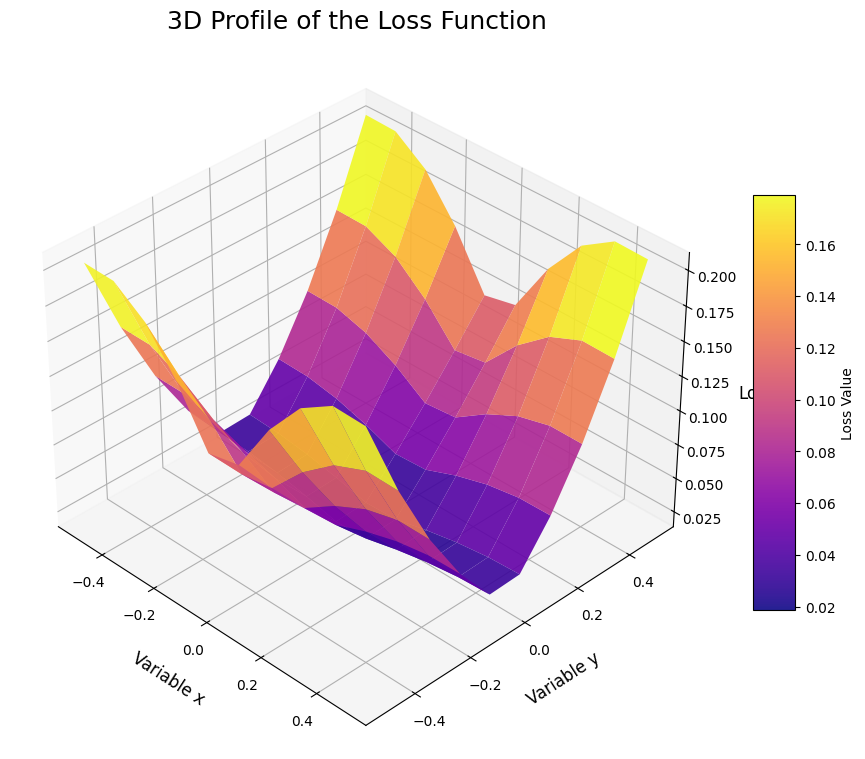

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm # Colormaps
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import itertools # We'll use this to create a clean loop for tqdm
from tqdm.auto import tqdm # Import tqdm for the 
# ==============================================================================
# ## STEP 1: DEFINE YOUR LOSS FUNCTION HERE ##
# ==============================================================================
#
# Replace the example function below with your `loss_ff`.
# It must take two scalar inputs (your 2D variable) and return one scalar output (the loss).
#

def loss_infunc(x, y):
    return loss_ff(jnp.array([x, y]), x_interval_example,
              dt,
              FaultyNonHolonomicCar(),
              p_nominal,
              p_actuator_fault,
              num_steps
            )

# ==============================================================================
# ## STEP 2: DEFINE THE DOMAIN TO PLOT ##
# ==============================================================================
#
# TODO: Adjust these ranges to fit your function's domain of interest.
#       For example, if your weights are always between -2 and 2, set that here.
#
x_var_range = np.linspace(-5, 5, 60)  # Range for 'x'
y_var_range = np.linspace(-5, 5, 60)  # Range for 'y'
# Note: Using 60x60 = 3600 points. Increase for higher resolution, decrease for faster calculation.

# Create a meshgrid from the ranges
X, Y = np.meshgrid(x_var_range, y_var_range)

# ==============================================================================
# ## STEP 3: CALCULATE THE LOSS FOR EACH POINT ON THE GRID ##
# ==============================================================================
#
# We loop through each point on the grid and call your `loss_infunc`.
# This approach works even if `loss_ff` is not "vectorized" for NumPy arrays.

print(f"Calculating loss for {X.size} points. This may take a moment...")

# Initialize an empty array for the Z values (the loss)
Z = np.zeros_like(X)

x_var_range = np.linspace(-.5, .5, 10)  # Range for 'x'
y_var_range = np.linspace(-.5, .5, 10)  # Range for 'y'
# Note: Using 80x80 = 6400 points. Increase for higher resolution, decrease for faster calculation.

# Create a meshgrid from the ranges
X, Y = np.meshgrid(x_var_range, y_var_range)

# ==============================================================================
# ## STEP 3: CALCULATE THE LOSS (WITH PROGRESS BAR) ##
# ==============================================================================

print(f"Preparing to calculate loss for {X.size} points...")

# Initialize an empty array for the Z values (the loss)
Z = np.zeros_like(X)

# Get the grid dimensions
rows, cols = X.shape

# Use itertools.product to create a single iterable for all grid points
# Then wrap it with tqdm to create the progress bar
grid_iterator = itertools.product(range(rows), range(cols))

for i, j in tqdm(grid_iterator, total=X.size, desc="Calculating Loss"):
    # Get the x, y coordinates for this grid point
    x_val = X[i, j]
    y_val = Y[i, j]
    # Calculate the loss and store it in the Z matrix
    Z[i, j] = loss_infunc(x_val, y_val)

print("Calculation complete.")

# ==============================================================================
# ## STEP 4: CREATE AND CUSTOMIZE THE 3D PLOT ##
# ==============================================================================
print("Generating 3D plot...")

# Create a figure and a 3D axis
fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap=cm.plasma, antialiased=True, alpha=0.9)

# Customize the axes labels
ax.set_xlabel('Variable x', fontsize=12, labelpad=10)
ax.set_ylabel('Variable y', fontsize=12, labelpad=10)
ax.set_zlabel('Loss', fontsize=12, labelpad=10)
ax.set_title('3D Profile of the Loss Function', fontsize=18, pad=20)

# Add a color bar
fig.colorbar(surf, shrink=0.6, aspect=10, label='Loss Value')

# Adjust the viewing angle for a better perspective
ax.view_init(elev=35, azim=-45)

# Show the plot
plt.show()

With feedback


In [ ]:
import jax
import jax.numpy as jnp
import numpy as np  # <<< IMPORT numpy
from scipy.optimize import minimize
import immrax as irx # Assuming this is your library for intervals

# --- Assume all your other functions (loss, propagate, etc.) are defined here ---

# Your objective function (no changes needed here)
def jax_objective(params, x_interval, dt, system1, system2, p_nominal, p_actuator_fault, num_steps):
    """A pure JAX function that takes the flat param vector and static args."""
    u_ol = params[0:2]
    K = params[2:].reshape((2, 2))
    return loss(u_ol, K, x_interval, dt, system1, system2, p_nominal, p_actuator_fault, num_steps)

#
# >>>>> THIS IS WHERE YOU MAKE THE CHANGE <<<<<
#
# OLD LINE (to be removed):
# value_and_grad_fn = jax.jit(jax.value_and_grad(jax_objective, argnums=0))
#
# NEW, CORRECTED BLOCK:
# Tell JIT to treat arguments 1 through 7 as static constants.
# It will only trace argument 0 ('params').
value_and_grad_fn = jax.jit(
    jax.value_and_grad(jax_objective, argnums=0),
    static_argnums=(1, 2, 3, 4, 5, 6, 7)  # <<< CORRECTED static_argnums
)


# The final wrapper for SciPy now calls this JAX function
def scipy_wrapper_with_grad(params, *args):
    # We must convert JAX arrays to NumPy arrays for SciPy.
    # JAX handles the conversion of numpy inputs automatically.
    value, grad = value_and_grad_fn(params, *args)
    # SciPy optimizers work with float64 by default, so ensure type compatibility.
    # It's safer to return standard numpy arrays.
    return np.float64(value), np.float64(grad) # <<< CHANGED to np.float64


# --- Setup for the optimization ---

# Use numpy for the initial parameters that go into the SciPy function
initial_params = np.concatenate([np.zeros(2), np.zeros((2, 2)).flatten()])

# Example fixed arguments (assuming your setup)
x_interval_example = irx.interval(jnp.array([0., 0., 0., 0.]), jnp.array([0.02, 0.02, 0.02, 0.02]))
dt = 0.1 # Using a float for dt
num_steps = 10
p_nominal = irx.icentpert(jnp.array([1.]), jnp.array([0.])) # Assuming valid interval
p_actuator_fault = irx.icentpert(jnp.array([0.25]), jnp.array([0.25]))

# Assume normal_car_embedding_system is defined
# from your_file import normal_car_embedding_system

fixed_args = (x_interval_example,
              dt,
              normal_car_embedding_system,
              normal_car_embedding_system,
              p_nominal,
              p_actuator_fault,
              num_steps
            )

print("\nStarting gradient-based optimization with JAX...")
# Use a method that can leverage gradients, like 'BFGS' or 'L-BFGS-B'
# Tell SciPy that our function returns the jacobian (gradient) by setting jac=True
result_grad = minimize(
    scipy_wrapper_with_grad,
    initial_params,
    args=fixed_args,
    method='L-BFGS-B',
    jac=True,  # <<< IMPORTANT! UNCOMMENTED THIS LINE
    options={'disp': True} # <<< UNCOMMENTED to see optimizer progress
)

# Extract and display the results
if result_grad.success:
    print("\nGradient-based optimization successful!")
    optimal_params = result_grad.x
    optimal_u_ol = optimal_params[0:2]
    optimal_K = optimal_params[2:].reshape((2, 2))
    print(f"Optimal u_ol:\n{optimal_u_ol}")
    print(f"Optimal K:\n{optimal_K}")
    print(f"Minimum loss value: {result_grad.fun}")
else:
    print("\nGradient-based optimization failed.")
    print(f"Message: {result_grad.message}")


Starting gradient-based optimization with JAX...

Gradient-based optimization successful!RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.26399D-03    |proj g|=  0.00000D+00

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6      0      1      0     0     0   0.000D+00   3.264D-03
  F =   3.2639945857226849E-003

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            

Optimal u_ol:
[0. 0.]
Optimal K:
[[0. 0.]
 [0. 0.]]
Minimum loss value: 0.003263994585722685


 This problem is unconstrained.


In [ ]:
print(result_grad.x)

[-6.78194206e-15 -2.71565716e-14]


In [ ]:
from visualization_functions import visualize_trajectory_given_u_K
u_ol = result_grad.x[0:2]
K = result_grad.x[2:].reshape((2, 2))
K_large = jnp.array([[result_grad.x[2], result_grad.x[3], 0, 0], [result_grad.x[4], result_grad.x[5], 0, 0]])  # Example large gain matrix
# Now you can use u_ol and K in your control system
# Propagate the system with the optimal control input
visualize_trajectory_given_u_K(
    x0_interval=irx.interval(jnp.array([0., 0., 0., 0.]), jnp.array([0.02, 0.02, 0.02, 0.02])),
    u_ol=u_ol,
    K=K_large,
    dt=1.0,
    w_interval=w_interval_no_fault,
    p_no_disturbance=p_no_disturbance,
    p_actuator_fault=p_interval,
    max_iter=10,
)

ValueError: cannot reshape array of size 0 into shape (2,2)

In [ ]:
K_opt = optimize_K(
    x_interval=x0_interval,
    dt=1,
    faulty_system=faulty_car_embedding_system,  # Your faulty system dynamics
    p_actuator_fault=irx.icentpert(jnp.array([.5]), jnp.array([0])),
    learning_rate=.1,
    max_iter=5
)

TypeError: Error interpreting argument to <function loss at 0x7a9f4c739260> as an abstract array. The problematic value is of type <class 'immrax.embedding.TransformEmbedding'> and was passed to the function at path faulty_system.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

In [ ]:
import profile
import re

Traced<ShapedArray(float32[4])>with<JVPTrace> with
  primal = Array([-0.04      , -0.02039997,  0.7653982 ,  0.7653982 ], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7a9c7eaf9980>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>), out_tracer_refs=[<weakref at 0x7a9c7e2ed030; to 'JaxprTracer' at 0x7a9c7e2ec180>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] = mul b d
    g:f32[4] = add_any e f
  in (g,) }, 'in_shardings': (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue), 'out_shardings': (UnspecifiedValue,), 'in_layouts': (None, None, None, None), 'out_layouts': (None,), 'donated_inva

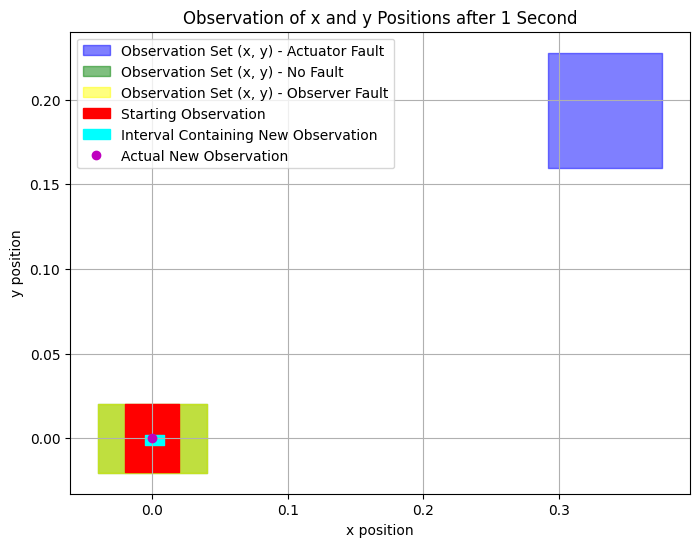

'observer'

In [ ]:
fault_detection(
    x0_interval=x0_interval, 
    w_interval=w_interval, 
    p_no_disturbance=irx.icentpert(jnp.zeros(1), jnp.zeros(1)),
    p_actuator_fault=irx.icentpert(jnp.array([.5]), jnp.array([0])),
    observer_offset=jnp.array([.2, .2, .2, .2,]),
    dt=1,
    max_iter=10,
    )

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x70785bb188d0>>
Traceback (most recent call last):
  File "/home/user/anaconda3/envs/brendan-immrax/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

  File "/home/user/anaconda3/envs/brendan-immrax/lib/python3.11/profile.py", line 208, in trace_dispatch_i
    if self.dispatch[event](self, frame, t):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/anaconda3/envs/brendan-immrax/lib/python3.11/profile.py", line 261, in trace_dispatch_call
    assert rframe.f_back is frame.f_back, ("Bad call", rfn,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: ('Bad call', ('/home/user/anaconda3/envs/brendan-immrax/lib/python3.11/site-packages/jax/_src/interpreters/partial_eval.py', 2566, 'inline_jaxpr_into_trace'), <frame at 0x70737669e700, file '/home/user/anaconda3/envs/br

Traced<ShapedArray(float32[4])>with<JVPTrace> with
  primal = Array([0.2923992 , 0.17960009, 0.76539874, 0.76539874], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7073b78caae0>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>), out_tracer_refs=[<weakref at 0x70739be275b0; to 'JaxprTracer' at 0x70739be27510>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] = mul b d
    g:f32[4] = add_any e f
  in (g,) }, 'in_shardings': (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue), 'out_shardings': (UnspecifiedValue,), 'in_layouts': (None, None, None, None), 'out_layouts': (None,), 'donated_invars':

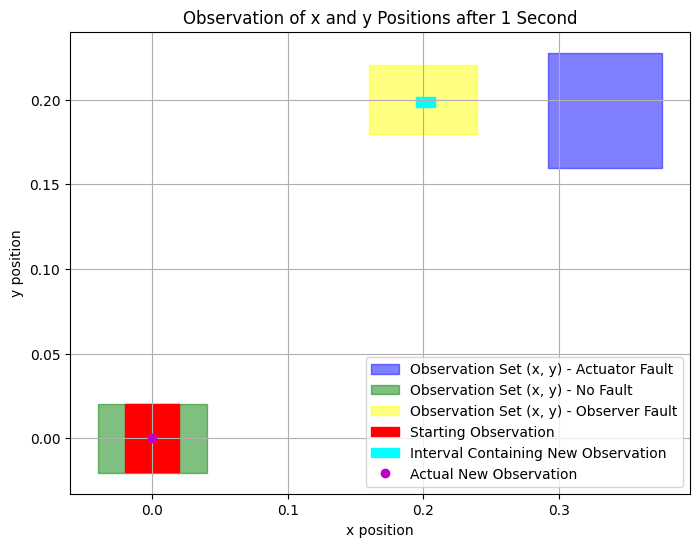

Traced<ShapedArray(float32[4])>with<JVPTrace> with
  primal = Array([0.6929709 , 0.4498155 , 0.76903266, 0.97065157], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x70773c3b5970>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>), out_tracer_refs=[<weakref at 0x7075e3c66250; to 'JaxprTracer' at 0x707399c9fbf0>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] = mul b d
    g:f32[4] = add_any e f
  in (g,) }, 'in_shardings': (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue), 'out_shardings': (UnspecifiedValue,), 'in_layouts': (None, None, None, None), 'out_layouts': (None,), 'donated_invars':

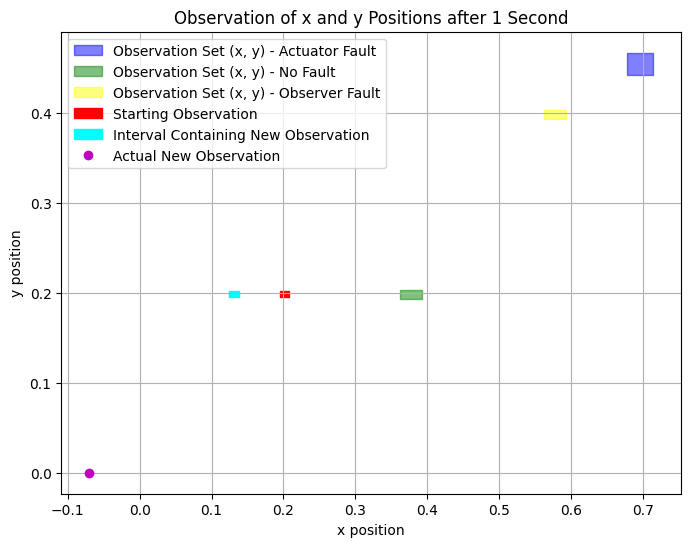

         27832 function calls (27419 primitive calls) in 97.217 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   97.196   97.196 1235443971.py:35(gradient_descent_armijo)
        1    0.000    0.000   97.193   97.193 1235443971.py:50(actuator_observer_intervals_given_x)
        1    0.000    0.000   97.193   97.193 1235443971.py:59(actuator_observer_fault_overlap_given_x)
        1    0.000    0.000   97.146   97.146 2631417610.py:1(propagate_interval)
        1    0.000    0.000    0.000    0.000 2631417610.py:11(w_map_in_func)
        1    0.000    0.000    0.000    0.000 2631417610.py:13(p_map_in_func)
        1    0.000    0.000    0.000    0.000 2631417610.py:9(u_map_in_func)
        1    0.000    0.000   97.198   97.198 643624110.py:4(fault_detection)
        6    0.000    0.000    0.000    0.000 :0(__build_class__)
       22    0.000    0.000    0.000    0.000 :0(__contains__)
        9  

In [ ]:
profile.run("fault_detection( \
    x0_interval=x0_interval,  \
    w_interval=w_interval,  \
    p_no_disturbance=irx.icentpert(jnp.zeros(1), jnp.zeros(1)), \
    p_actuator_fault=irx.icentpert(jnp.array([.5]), jnp.array([0])), \
    observer_offset=jnp.array([.2, .2, .2, .2,]), \
    dt=1,\
    max_iter=10,\
    )")

In [ ]:
from jax import grad, jacfwd, jacrev
# overlap_size(x_interval_actuator_fault[0:2], x_interval_observation_fault[0:2])
# overlap_size_grad = grad(actuator_observer_fault_overlap)
overlap_size_jacobian = grad(actuator_observer_fault_overlap)
# print("Overlap size Gradient", overlap_size_grad(jnp.array([.1, .1])))
# propagate_interval_jacobian = jacrev(propagate_interval)
# print("Propagate interval Reverse Jacobian", propagate_interval_jacobian(normal_car_embedding_system, x0_interval, u_fixed, w_fixed, p_interval, 1.0))
print("Overlap size Forward Jacobian", overlap_size_jacobian(x0_interval, jnp.array([.1, .1])))

Traced<ConcreteArray([0.15918237 0.08502489 0.685398   0.78539807], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([0.15918237, 0.08502489, 0.685398  , 0.78539807], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7fda11a5c630>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace(level=1/0)>, Traced<ShapedArray(float32[4]):JaxprTrace(level=1/0)>, Traced<ConcreteArray([1. 0. 1. 1.], dtype=float32):JaxprTrace(level=1/0)>, Traced<ConcreteArray([0. 1. 0. 0.], dtype=float32):JaxprTrace(level=1/0)>), out_tracer_refs=[<weakref at 0x7fd98d5d1760; to 'JaxprTracer' at 0x7fd98d5d1670>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] = mul b d
    g:f32[4] = add_any e f
  in (g,) }, 'in_shardings': (UnspecifiedValue, UnspecifiedValue

In [ ]:
# Gradient descent parameters
learning_rate = 10  # Step size for gradient descent
max_iterations = 10  # Maximum number of iterations
tolerance = 1e-6  # Convergence tolerance

# Initial control input (replace with your initial guess)
u = jnp.array([0.0, 0.0])

# Gradient descent loop
for i in range(max_iterations):
    # Compute the overlap size and its gradient
    intersection_size = actuator_observer_fault_overlap(u)
    gradient = overlap_size_jacobian(u)
    
    # Check for convergence
    if jnp.abs(intersection_size) < tolerance:
        print(f"Converged at iteration {i} with overlap size {intersection_size}")
        break
    
    # Update the control input using gradient descent
    u = u - learning_rate * gradient
    
    # Print progress
 
    print(f"Iteration {i}: overlap size = {intersection_size}, u = {u}")

[0.3273081  0.22949149 0.685398   0.885398  ]
[0.54513395 0.3717006  0.88539785 0.88539785]
Traced<ConcreteArray([0.3273081  0.22949149 0.685398   0.885398  ], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([0.3273081 , 0.22949149, 0.685398  , 0.885398  ], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x739219f84040>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace(level=1/0)>, Traced<ShapedArray(float32[4]):JaxprTrace(level=1/0)>, Traced<ConcreteArray([0.  0.  0.5 0. ], dtype=float32):JaxprTrace(level=1/0)>, Traced<ConcreteArray([1.  1.  0.5 1. ], dtype=float32):JaxprTrace(level=1/0)>), out_tracer_refs=[<weakref at 0x739134bc2610; to 'JaxprTracer' at 0x739134bc1a80>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] =

In [ ]:
print("Optimal u: ", u)

Optimal u:  [0. 0.]


In [ ]:
optimal_u = u
optimal_u_interval = irx.icentpert(optimal_u, jnp.zeros_like(optimal_u))
x_interval_no_fault = propagate_interval(normal_car_system, x0_interval, optimal_u_interval, w_interval, p_no_disturbance, t_end)
x_interval_actuator_fault = propagate_interval(car_system, x0_interval=x0_interval, u_interval=optimal_u_interval, w_interval=w_interval, p_interval=p_interval, t_end=t_end)
x_interval_observation_fault = x_interval_no_fault + offset

TypeError: Unexpected input type for array: <class 'immrax.inclusion.interval.Interval'>

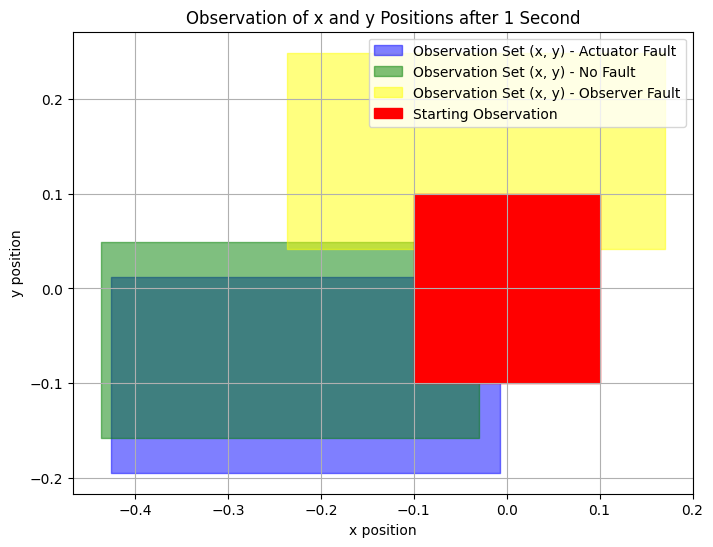

In [ ]:
plot_observation_boxes(x_interval_no_fault=x_interval_no_fault, x_interval_actuator_fault=x_interval_actuator_fault, x_interval_observation_fault=x_interval_observation_fault)